In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [1]:
import sys
sys.path.append("..")
from src.pose_extractor import extract_keypoints_from_video
from src.renderer import draw_skeleton
import cv2

video_path = "../data/raw_clips/header/header_02.mp4"
keypoints = extract_keypoints_from_video(video_path)
print("Shape:", keypoints.shape)

WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8n-pose.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>


#=#=#                                                                          

##O=#  #                                                                       

#=#=-#  #                                                                      

##                                                                         2.9%

...

################################################                          67.2%

############################################################              84.5%

######################################################################## 100.0%


2026-07-18 23:33:12,663 - INFO - Extracted keypoints for 50 frames from ../data/raw_clips/header/header_02.mp4


Shape: (50, 17, 3)


In [4]:
import matplotlib.pyplot as plt

side-by-side original vs. skeleton

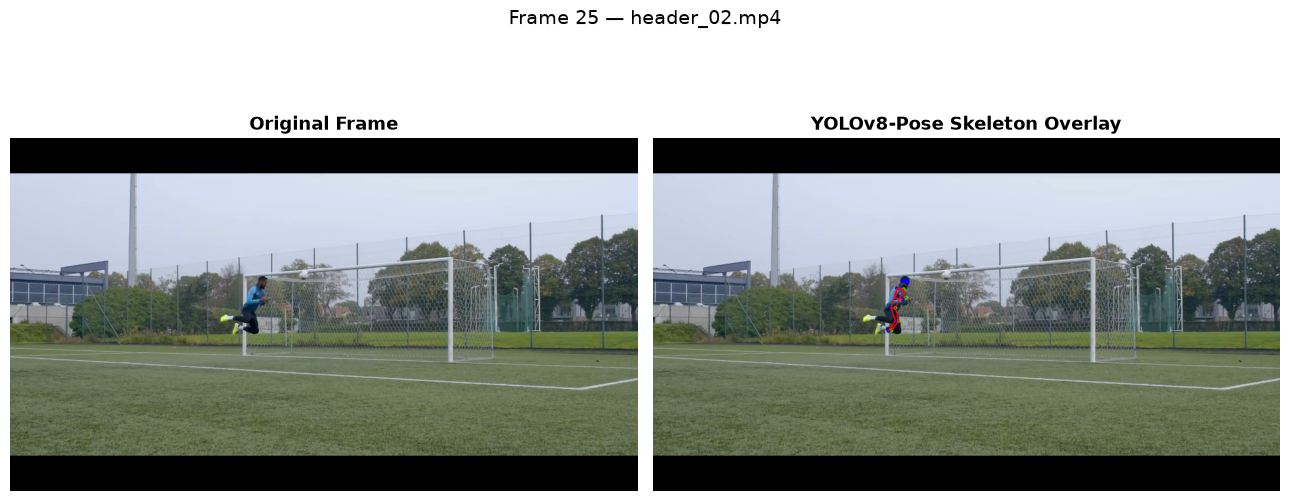

In [7]:
cap = cv2.VideoCapture(video_path)
frame_idx = 25
for i in range(frame_idx + 1):
    ret, frame = cap.read()
cap.release()

annotated = draw_skeleton(frame, keypoints[frame_idx])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Frame", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title("YOLOv8-Pose Skeleton Overlay", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.suptitle(f"Frame {frame_idx} — header_02.mp4", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

filled confidence area chart

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#0f4c3a", "#1a7a5e", "#2fa084", "#5cbfa3", "#8ad4bf", "#b8e6d8"]
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.edgecolor"] = "#cccccc"

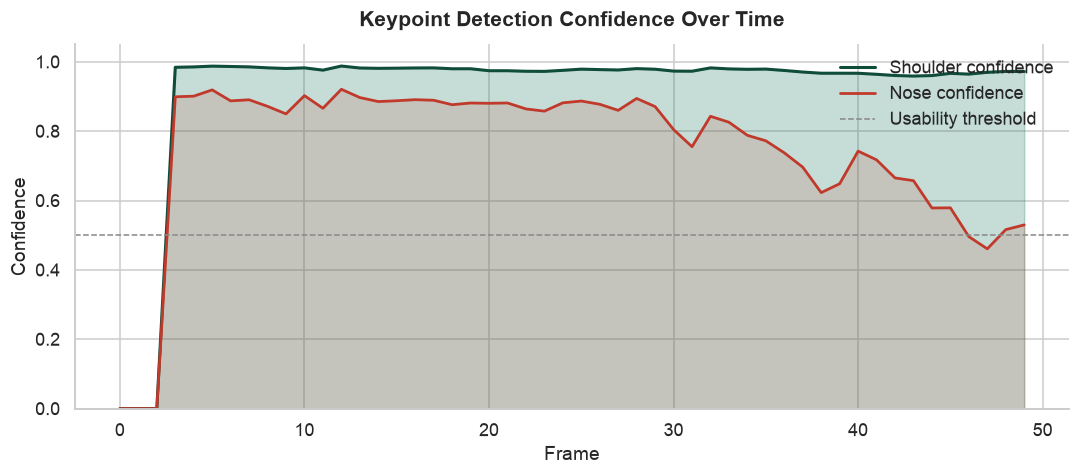

In [12]:
nose_conf = keypoints[:, 0, 2]
shoulder_conf = (keypoints[:, 5, 2] + keypoints[:, 6, 2]) / 2
frames = range(len(keypoints))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(frames, shoulder_conf, alpha=0.25, color=PALETTE[1])
ax.plot(frames, shoulder_conf, color=PALETTE[0], linewidth=2, label="Shoulder confidence")
ax.fill_between(frames, nose_conf, alpha=0.15, color="#c0392b")
ax.plot(frames, nose_conf, color="#c0392b", linewidth=1.8, label="Nose confidence")
ax.axhline(0.5, color="#888", linestyle="--", linewidth=1, label="Usability threshold")

ax.set_title("Keypoint Detection Confidence Over Time", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Frame")
ax.set_ylabel("Confidence")
ax.set_ylim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()